In [1]:
import numpy as np
import pandas as pd
import re
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import collections
import itertools
import seaborn as sns
import tweepy
import datetime
import nltk
from nltk.corpus import stopwords
from PIL import Image
import datetime
from afinn import Afinn
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer  
from sklearn.feature_extraction.text import TfidfVectorizer
import operator
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from networkx.drawing.nx_agraph import graphviz_layout
import nltk

In [132]:
df = pd.read_excel('C:/Users/jwan0/Youtubecrawl_JP_1108.xlsx')

df.head()

,Unnamed: 0,Unnamed: 0.1,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,neg,neu,pos,compound,sentiment
0,0,0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹,"['love', 'japan', 'italy']",love japan italy,love japan italy,love japan italy,True,0.000,0.323,0.677,0.6369,positive
1,1,1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre0:02 tokyo tower0:08 toudai-j...,"['0', '01', 'tokyo', 'skytre0', '02', 'tokyo',...",tokyo skytre0 tokyo tower0 toudai temple0 know...,tokyo skytre0 tokyo tower0 toudai temple0 know...,tokyo skytre0 tokyo tower0 toudai temple0 know...,True,0.045,0.833,0.122,0.7506,positive
2,2,2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...,"['japan', 'wonder', 'love', 'india']",japan wonder love india,japan wonder love india,japan wonder love india,True,0.000,0.417,0.583,0.6369,positive
3,3,3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...,"['currently', 'learning', 'japanese', 'see', '...",currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,True,0.000,0.792,0.208,0.6369,positive
4,4,4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...,"['watching', 'video', 'makes', 'feel', 'happy'...",watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,True,0.000,0.442,0.558,0.9918,positive


In [133]:
df = df.astype('string')
df.dtypes

Unnamed: 0             string
Unnamed: 0.1           string
id                     string
content of comments    string
Translation            string
text_token             string
text_string            string
text_string_fdist      string
text_string_lem        string
is_equal               string
neg                    string
neu                    string
pos                    string
compound               string
sentiment              string
dtype: object

In [134]:
import texthero as hero
from texthero import preprocessing
custom_pipeline = [preprocessing.fillna,
                   #preprocessing.lowercase,
                   preprocessing.remove_whitespace,
                   preprocessing.remove_diacritics
                   #preprocessing.remove_brackets
                  ]
df['clean_text'] = hero.clean(df['Translation'], custom_pipeline)
df['clean_text'] = [n.replace('{','') for n in df['clean_text']]
df['clean_text'] = [n.replace('}','') for n in df['clean_text']]
df['clean_text'] = [n.replace('(','') for n in df['clean_text']]
df['clean_text'] = [n.replace(')','') for n in df['clean_text']]

df.head()

,Unnamed: 0,Unnamed: 0.1,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,neg,neu,pos,compound,sentiment,clean_text
0,0,0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹,"['love', 'japan', 'italy']",love japan italy,love japan italy,love japan italy,True,0.0,0.323,0.677,0.6369,positive,love japan! from italy
1,1,1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre0:02 tokyo tower0:08 toudai-j...,"['0', '01', 'tokyo', 'skytre0', '02', 'tokyo',...",tokyo skytre0 tokyo tower0 toudai temple0 know...,tokyo skytre0 tokyo tower0 toudai temple0 know...,tokyo skytre0 tokyo tower0 toudai temple0 know...,True,0.045,0.833,0.122,0.7506,positive,0:01 tokyo skytre0:02 tokyo tower0:08 toudai-j...
2,2,2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...,"['japan', 'wonder', 'love', 'india']",japan wonder love india,japan wonder love india,japan wonder love india,True,0.0,0.417,0.583,0.6369,positive,japan is such a wonder to me. love from india!
3,3,3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...,"['currently', 'learning', 'japanese', 'see', '...",currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,True,0.0,0.792,0.208,0.6369,positive,i'm currently learning japanese and when i see...
4,4,4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...,"['watching', 'video', 'makes', 'feel', 'happy'...",watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,True,0.0,0.442,0.558,0.9918,positive,watching this video makes me feel happy to be ...


In [135]:
df['Translation'] = df['Translation'].astype(str).str.lower()
df.head()

,Unnamed: 0,Unnamed: 0.1,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,neg,neu,pos,compound,sentiment,clean_text
0,0,0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹,"['love', 'japan', 'italy']",love japan italy,love japan italy,love japan italy,True,0.0,0.323,0.677,0.6369,positive,love japan! from italy
1,1,1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre0:02 tokyo tower0:08 toudai-j...,"['0', '01', 'tokyo', 'skytre0', '02', 'tokyo',...",tokyo skytre0 tokyo tower0 toudai temple0 know...,tokyo skytre0 tokyo tower0 toudai temple0 know...,tokyo skytre0 tokyo tower0 toudai temple0 know...,True,0.045,0.833,0.122,0.7506,positive,0:01 tokyo skytre0:02 tokyo tower0:08 toudai-j...
2,2,2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...,"['japan', 'wonder', 'love', 'india']",japan wonder love india,japan wonder love india,japan wonder love india,True,0.0,0.417,0.583,0.6369,positive,japan is such a wonder to me. love from india!
3,3,3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...,"['currently', 'learning', 'japanese', 'see', '...",currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,True,0.0,0.792,0.208,0.6369,positive,i'm currently learning japanese and when i see...
4,4,4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...,"['watching', 'video', 'makes', 'feel', 'happy'...",watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,True,0.0,0.442,0.558,0.9918,positive,watching this video makes me feel happy to be ...


In [136]:
from nltk.tokenize import RegexpTokenizer

regexp = RegexpTokenizer('\w+')

df['text_token']=df['Translation'].apply(regexp.tokenize)
df.head()

,Unnamed: 0,Unnamed: 0.1,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,neg,neu,pos,compound,sentiment,clean_text
0,0,0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹,"[love, japan, from, italy]",love japan italy,love japan italy,love japan italy,True,0.0,0.323,0.677,0.6369,positive,love japan! from italy
1,1,1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre0:02 tokyo tower0:08 toudai-j...,"[0, 01, tokyo, skytre0, 02, tokyo, tower0, 08,...",tokyo skytre0 tokyo tower0 toudai temple0 know...,tokyo skytre0 tokyo tower0 toudai temple0 know...,tokyo skytre0 tokyo tower0 toudai temple0 know...,True,0.045,0.833,0.122,0.7506,positive,0:01 tokyo skytre0:02 tokyo tower0:08 toudai-j...
2,2,2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...,"[japan, is, such, a, wonder, to, me, love, fro...",japan wonder love india,japan wonder love india,japan wonder love india,True,0.0,0.417,0.583,0.6369,positive,japan is such a wonder to me. love from india!
3,3,3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...,"[i, m, currently, learning, japanese, and, whe...",currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,True,0.0,0.792,0.208,0.6369,positive,i'm currently learning japanese and when i see...
4,4,4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...,"[watching, this, video, makes, me, feel, happy...",watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,True,0.0,0.442,0.558,0.9918,positive,watching this video makes me feel happy to be ...


In [137]:
stopwords = nltk.corpus.stopwords.words("english")

# Extend the list with your own custom stopwords
my_stopwords = ['https', 'and', 'this','from','you','that','for','was','are','can','but','all','who','what','where','your','really',
               'made', 'well', 'anyone','guys','name','much', 'put','ever','could', 'one', 'done','come','www','may', 'hey', 'chan',
                'someday', 'still','yet','somehow','first', 'yoooo', '2021', '2020', 'truly', '2019','also', 'degree', 'units', 'skip', 
                'hello', 'soon', 'even', 'really', 'going','greeting', 'come', 'next','looks', 'ahhhh', 'desu', 'get', 'got', 'guy', 
                'make', 'qua','watashi', 'okay', 'yuri', 'com', 'back', 'wait', 'thought','past']
stopwords.extend(my_stopwords)

In [ ]:
#stopword list
#'https', 'and', 'this','from','you','that','for','was','are','can','but','all','who','what','where','your','really',

In [138]:
df['text_token'] = df['text_token'].apply(lambda x: [item for item in x if item not in stopwords])
df.head()

,Unnamed: 0,Unnamed: 0.1,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,neg,neu,pos,compound,sentiment,clean_text
0,0,0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹,"[love, japan, italy]",love japan italy,love japan italy,love japan italy,True,0.0,0.323,0.677,0.6369,positive,love japan! from italy
1,1,1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre0:02 tokyo tower0:08 toudai-j...,"[0, 01, tokyo, skytre0, 02, tokyo, tower0, 08,...",tokyo skytre0 tokyo tower0 toudai temple0 know...,tokyo skytre0 tokyo tower0 toudai temple0 know...,tokyo skytre0 tokyo tower0 toudai temple0 know...,True,0.045,0.833,0.122,0.7506,positive,0:01 tokyo skytre0:02 tokyo tower0:08 toudai-j...
2,2,2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...,"[japan, wonder, love, india]",japan wonder love india,japan wonder love india,japan wonder love india,True,0.0,0.417,0.583,0.6369,positive,japan is such a wonder to me. love from india!
3,3,3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...,"[currently, learning, japanese, see, video, re...",currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,True,0.0,0.792,0.208,0.6369,positive,i'm currently learning japanese and when i see...
4,4,4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...,"[watching, video, makes, feel, happy, born, be...",watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,True,0.0,0.442,0.558,0.9918,positive,watching this video makes me feel happy to be ...


In [139]:
df['text_string'] = df['text_token'].apply(lambda x: ' '.join([item for item in x if len(item)>2]))

df.head()

,Unnamed: 0,Unnamed: 0.1,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,neg,neu,pos,compound,sentiment,clean_text
0,0,0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹,"[love, japan, italy]",love japan italy,love japan italy,love japan italy,True,0.0,0.323,0.677,0.6369,positive,love japan! from italy
1,1,1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre0:02 tokyo tower0:08 toudai-j...,"[0, 01, tokyo, skytre0, 02, tokyo, tower0, 08,...",tokyo skytre0 tokyo tower0 toudai temple0 know...,tokyo skytre0 tokyo tower0 toudai temple0 know...,tokyo skytre0 tokyo tower0 toudai temple0 know...,True,0.045,0.833,0.122,0.7506,positive,0:01 tokyo skytre0:02 tokyo tower0:08 toudai-j...
2,2,2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...,"[japan, wonder, love, india]",japan wonder love india,japan wonder love india,japan wonder love india,True,0.0,0.417,0.583,0.6369,positive,japan is such a wonder to me. love from india!
3,3,3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...,"[currently, learning, japanese, see, video, re...",currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,True,0.0,0.792,0.208,0.6369,positive,i'm currently learning japanese and when i see...
4,4,4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...,"[watching, video, makes, feel, happy, born, be...",watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,True,0.0,0.442,0.558,0.9918,positive,watching this video makes me feel happy to be ...


In [140]:
df[['Translation', 'text_token', 'text_string']].head()

,Translation,text_token,text_string
0,love japan! from italy 🇮🇹,"[love, japan, italy]",love japan italy
1,0:01 tokyo skytre0:02 tokyo tower0:08 toudai-j...,"[0, 01, tokyo, skytre0, 02, tokyo, tower0, 08,...",tokyo skytre0 tokyo tower0 toudai temple0 know...
2,japan is such a wonder to me. love from india!...,"[japan, wonder, love, india]",japan wonder love india
3,i'm currently learning japanese and when i see...,"[currently, learning, japanese, see, video, re...",currently learning japanese see video reminds ...
4,watching this video makes me feel happy to be ...,"[watching, video, makes, feel, happy, born, be...",watching video makes feel happy born beautiful...


In [141]:
#nltk.download('punkt')

#Create a list of all words
all_words = ' '.join([word for word in df['text_string']])

#Tokenize all_words
tokenized_words = nltk.tokenize.word_tokenize(all_words)

#Create a frequency distribution which records the number of times each word has occurred:

from nltk.probability import FreqDist

fdist = FreqDist(tokenized_words)
fdist

FreqDist({'japan': 730, 'love': 297, 'video': 238, 'country': 137, 'japanese': 130, 'beautiful': 128, 'like': 110, 'want': 80, 'people': 74, 'amazing': 74, ...})

In [142]:
df['text_string_fdist'] = df['text_token'].apply(lambda x: ' '.join([item for item in x if fdist[item] >= 1 ]))

In [143]:
df[['Translation','text_token', 'text_string', 'text_string_fdist']].head()

,Translation,text_token,text_string,text_string_fdist
0,love japan! from italy 🇮🇹,"[love, japan, italy]",love japan italy,love japan italy
1,0:01 tokyo skytre0:02 tokyo tower0:08 toudai-j...,"[0, 01, tokyo, skytre0, 02, tokyo, tower0, 08,...",tokyo skytre0 tokyo tower0 toudai temple0 know...,tokyo skytre0 tokyo tower0 toudai temple0 know...
2,japan is such a wonder to me. love from india!...,"[japan, wonder, love, india]",japan wonder love india,japan wonder love india
3,i'm currently learning japanese and when i see...,"[currently, learning, japanese, see, video, re...",currently learning japanese see video reminds ...,currently learning japanese see video reminds ...
4,watching this video makes me feel happy to be ...,"[watching, video, makes, feel, happy, born, be...",watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...


In [144]:
from nltk.stem import WordNetLemmatizer

wordnet_lem = WordNetLemmatizer()

df['text_string_lem'] = df['text_string_fdist'].apply(wordnet_lem.lemmatize)

In [145]:
df['is_equal']= (df['text_string_fdist']==df['text_string_lem'])

In [146]:
df.head()

,Unnamed: 0,Unnamed: 0.1,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,neg,neu,pos,compound,sentiment,clean_text
0,0,0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹,"[love, japan, italy]",love japan italy,love japan italy,love japan italy,True,0.0,0.323,0.677,0.6369,positive,love japan! from italy
1,1,1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre0:02 tokyo tower0:08 toudai-j...,"[0, 01, tokyo, skytre0, 02, tokyo, tower0, 08,...",tokyo skytre0 tokyo tower0 toudai temple0 know...,tokyo skytre0 tokyo tower0 toudai temple0 know...,tokyo skytre0 tokyo tower0 toudai temple0 know...,True,0.045,0.833,0.122,0.7506,positive,0:01 tokyo skytre0:02 tokyo tower0:08 toudai-j...
2,2,2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...,"[japan, wonder, love, india]",japan wonder love india,japan wonder love india,japan wonder love india,True,0.0,0.417,0.583,0.6369,positive,japan is such a wonder to me. love from india!
3,3,3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...,"[currently, learning, japanese, see, video, re...",currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,True,0.0,0.792,0.208,0.6369,positive,i'm currently learning japanese and when i see...
4,4,4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...,"[watching, video, makes, feel, happy, born, be...",watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,True,0.0,0.442,0.558,0.9918,positive,watching this video makes me feel happy to be ...


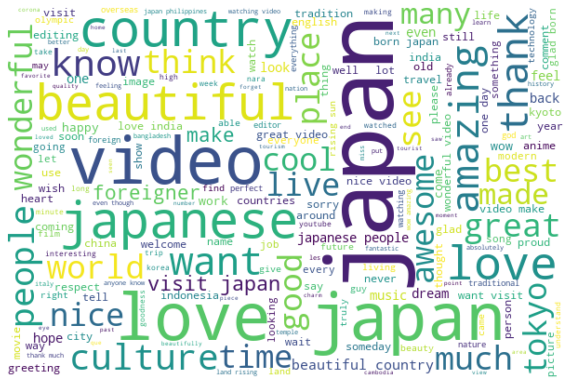

In [151]:
from wordcloud import WordCloud

all_words_lem = ' '.join([word for word in df['text_string_lem']])

wordcloud = WordCloud(width=600, 
                     height=400, 
                     random_state=2, 
                     background_color='white', 
                     max_font_size=100).generate(all_words_lem)


plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off');

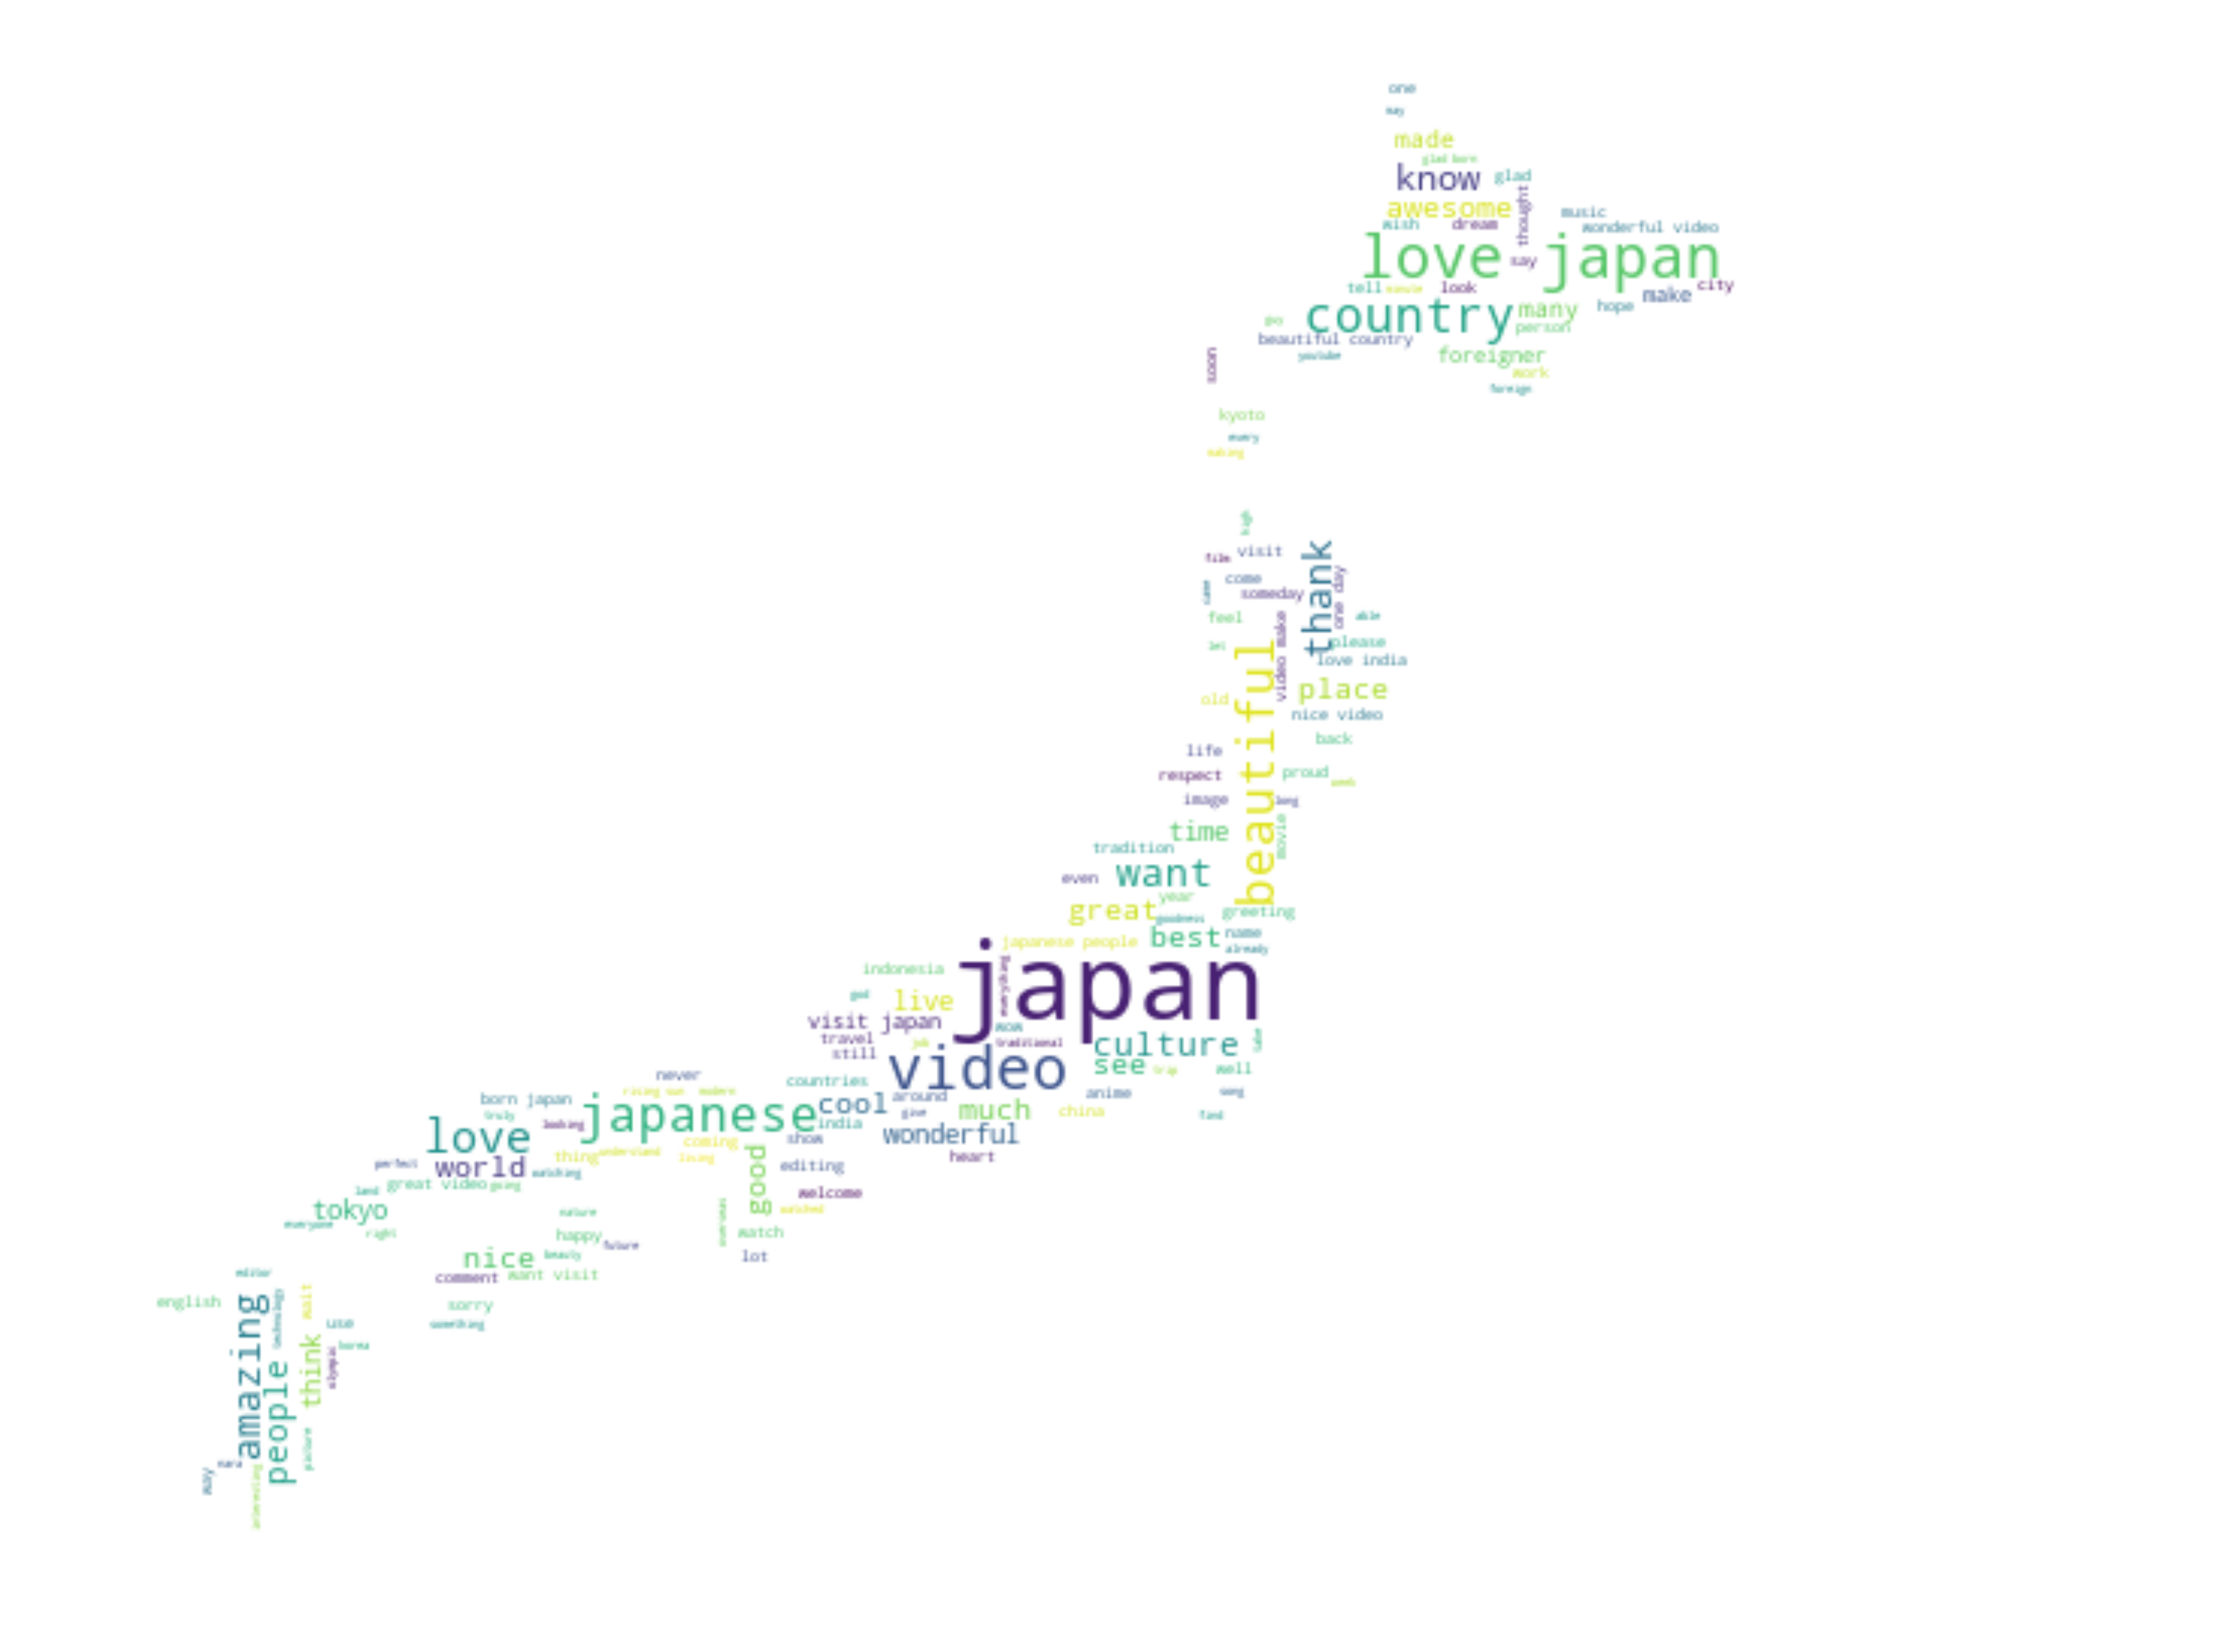

In [162]:
from wordcloud import WordCloud
mask = np.array(Image.open(r'C:\Users\jwan0\Geomap-asia-Japan.png'))
all_words_lem = ' '.join([word for word in df['text_string_lem']])

wordcloud = WordCloud(random_state=2, 
                     background_color='white', 
                     mask = mask,
                     width = mask.shape[1],
                     height = mask.shape[0],
                     max_font_size=500).generate(all_words_lem)


plt.figure(figsize=(100, 80))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off');

In [46]:
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

words = nltk.word_tokenize(all_words_lem)
fd = FreqDist(words)

In [47]:
fd.most_common(200)

[('roger', 80),
 ('switzerland', 76),
 ('anne', 56),
 ('love', 30),
 ('federer', 28),
 ('great', 28),
 ('beautiful', 26),
 ('hathaway', 25),
 ('views', 24),
 ('tour', 22),
 ('like', 21),
 ('swiss', 19),
 ('grand', 18),
 ('see', 17),
 ('time', 16),
 ('good', 15),
 ('people', 15),
 ('world', 15),
 ('need', 15),
 ('country', 14),
 ('next', 14),
 ('tennis', 13),
 ('abs', 13),
 ('nice', 12),
 ('lol', 12),
 ('james', 12),
 ('bond', 12),
 ('looks', 12),
 ('funny', 11),
 ('thing', 11),
 ('commercial', 11),
 ('know', 11),
 ('million', 11),
 ('much', 11),
 ('think', 11),
 ('get', 11),
 ('even', 10),
 ('would', 10),
 ('one', 10),
 ('may', 10),
 ('everything', 9),
 ('movie', 9),
 ('actor', 9),
 ('thought', 9),
 ('beauty', 8),
 ('many', 8),
 ('acting', 8),
 ('years', 8),
 ('hilarious', 8),
 ('place', 8),
 ('two', 8),
 ('want', 8),
 ('well', 8),
 ('sure', 7),
 ('going', 7),
 ('laughing', 7),
 ('done', 7),
 ('visit', 7),
 ('still', 7),
 ('better', 7),
 ('french', 7),
 ('got', 7),
 ('god', 7),
 ('lmao

In [48]:
word_rank = fd.most_common(200)

WR = pd.DataFrame(word_rank)

WR.to_excel('Word_top_200_sw.xlsx')

In [49]:
top_10 = fd.most_common(10)

fdist = pd.Series(dict(top_10))

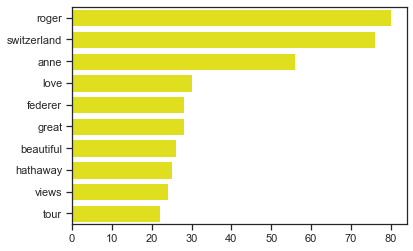

In [50]:
sns.set_theme(style="ticks")

sns.barplot(y=fdist.index, x=fdist.values, color='yellow');

In [51]:
from nltk.sentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

df['polarity'] = df['text_string_lem'].apply(lambda x: analyzer.polarity_scores(x))
df.head()

,Unnamed: 0,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,polarity
0,0,Traveling with Kristin,I’m not sure how any other country’s tourism b...,i’m not sure how any other country’s tourism b...,"[sure, country, tourism, board, going, beat]",sure country tourism board going beat,sure country tourism board going beat,sure country tourism board going beat,True,"{'neg': 0.0, 'neu': 0.685, 'pos': 0.315, 'comp..."
1,1,Sylvia Michel Photography - Switzerland's Best,The Grand Tour is only a fraction of what Swit...,the grand tour is only a fraction of what swit...,"[grand, tour, fraction, switzerland, offer, te...",grand tour fraction switzerland offer terms sc...,grand tour fraction switzerland offer terms sc...,grand tour fraction switzerland offer terms sc...,True,"{'neg': 0.0, 'neu': 0.431, 'pos': 0.569, 'comp..."
2,2,Kingsley CY,The paradox of acting:Anne Hathaway nailing ev...,the paradox of acting:anne hathaway nailing ev...,"[paradox, acting, anne, hathaway, nailing, eve...",paradox acting anne hathaway nailing every bea...,paradox acting anne hathaway nailing every bea...,paradox acting anne hathaway nailing every bea...,True,"{'neg': 0.094, 'neu': 0.804, 'pos': 0.102, 'co..."
3,3,Suradech Singhanat,Anne is just phenomenon in everything. I love ...,anne is just phenomenon in everything. i love ...,"[anne, phenomenon, everything, love]",anne phenomenon everything love,anne phenomenon everything love,anne phenomenon everything love,True,"{'neg': 0.0, 'neu': 0.417, 'pos': 0.583, 'comp..."
4,4,dj7oya,"Federer on the verge of laughing to his lines,...","federer on the verge of laughing to his lines,...","[federer, verge, laughing, lines, funny, thing]",federer verge laughing lines funny thing,federer verge laughing lines funny thing,federer verge laughing lines funny thing,True,"{'neg': 0.0, 'neu': 0.396, 'pos': 0.604, 'comp..."


In [52]:
df = pd.concat(
    [df.drop(['polarity'], axis=1), df['polarity'].apply(pd.Series)], axis=1)
df.head()

,Unnamed: 0,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,neg,neu,pos,compound
0,0,Traveling with Kristin,I’m not sure how any other country’s tourism b...,i’m not sure how any other country’s tourism b...,"[sure, country, tourism, board, going, beat]",sure country tourism board going beat,sure country tourism board going beat,sure country tourism board going beat,True,0.000,0.685,0.315,0.3182
1,1,Sylvia Michel Photography - Switzerland's Best,The Grand Tour is only a fraction of what Swit...,the grand tour is only a fraction of what swit...,"[grand, tour, fraction, switzerland, offer, te...",grand tour fraction switzerland offer terms sc...,grand tour fraction switzerland offer terms sc...,grand tour fraction switzerland offer terms sc...,True,0.000,0.431,0.569,0.9812
2,2,Kingsley CY,The paradox of acting:Anne Hathaway nailing ev...,the paradox of acting:anne hathaway nailing ev...,"[paradox, acting, anne, hathaway, nailing, eve...",paradox acting anne hathaway nailing every bea...,paradox acting anne hathaway nailing every bea...,paradox acting anne hathaway nailing every bea...,True,0.094,0.804,0.102,0.0314
3,3,Suradech Singhanat,Anne is just phenomenon in everything. I love ...,anne is just phenomenon in everything. i love ...,"[anne, phenomenon, everything, love]",anne phenomenon everything love,anne phenomenon everything love,anne phenomenon everything love,True,0.000,0.417,0.583,0.6369
4,4,dj7oya,"Federer on the verge of laughing to his lines,...","federer on the verge of laughing to his lines,...","[federer, verge, laughing, lines, funny, thing]",federer verge laughing lines funny thing,federer verge laughing lines funny thing,federer verge laughing lines funny thing,True,0.000,0.396,0.604,0.7269


In [53]:
df['sentiment'] = df['compound'].apply(lambda x: 'positive' if x >0 else 'neutral' if x==0 else 'negative')
df.head()

,Unnamed: 0,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,neg,neu,pos,compound,sentiment
0,0,Traveling with Kristin,I’m not sure how any other country’s tourism b...,i’m not sure how any other country’s tourism b...,"[sure, country, tourism, board, going, beat]",sure country tourism board going beat,sure country tourism board going beat,sure country tourism board going beat,True,0.000,0.685,0.315,0.3182,positive
1,1,Sylvia Michel Photography - Switzerland's Best,The Grand Tour is only a fraction of what Swit...,the grand tour is only a fraction of what swit...,"[grand, tour, fraction, switzerland, offer, te...",grand tour fraction switzerland offer terms sc...,grand tour fraction switzerland offer terms sc...,grand tour fraction switzerland offer terms sc...,True,0.000,0.431,0.569,0.9812,positive
2,2,Kingsley CY,The paradox of acting:Anne Hathaway nailing ev...,the paradox of acting:anne hathaway nailing ev...,"[paradox, acting, anne, hathaway, nailing, eve...",paradox acting anne hathaway nailing every bea...,paradox acting anne hathaway nailing every bea...,paradox acting anne hathaway nailing every bea...,True,0.094,0.804,0.102,0.0314,positive
3,3,Suradech Singhanat,Anne is just phenomenon in everything. I love ...,anne is just phenomenon in everything. i love ...,"[anne, phenomenon, everything, love]",anne phenomenon everything love,anne phenomenon everything love,anne phenomenon everything love,True,0.000,0.417,0.583,0.6369,positive
4,4,dj7oya,"Federer on the verge of laughing to his lines,...","federer on the verge of laughing to his lines,...","[federer, verge, laughing, lines, funny, thing]",federer verge laughing lines funny thing,federer verge laughing lines funny thing,federer verge laughing lines funny thing,True,0.000,0.396,0.604,0.7269,positive


In [54]:
df.loc[df['compound'].idxmax()].values
print()
# Tweet with highest negative sentiment 
# ...seems to be a case of wrong classification because of the word "deficit"
df.loc[df['compound'].idxmin()].values

array(['206', '  Paul Dockree',
       'Murren. Maybe I should use "Inferno" as a constant but why bother?  Yer think? Okay. Inferno\'s swell put out dazedly ~ You Need Switzerland Full Stop I have been to Switzerland twice I think. For one day trips. Twice. 1986 the last time. I recall because I ran a half marathon the self same year. Subject: The Intern You bad unreadable weapon you need Switzerland full stop_x000D_Anagram: Ladies frenzy Wound Tell – POTUS When you need an unbeatable road trip',
       'murren. maybe i should use "inferno" as a constant but why bother?  yer think? okay. inferno\'s swell put out dazedly ~ you need switzerland full stop i have been to switzerland twice i think. for one day trips. twice. 1986 the last time. i recall because i ran a half marathon the self same year. subject: the intern you bad unreadable weapon you need switzerland full stop_x000d_anagram: ladies frenzy wound tell – potus when you need an unbeatable road trip',
       list(['murren', 'ma

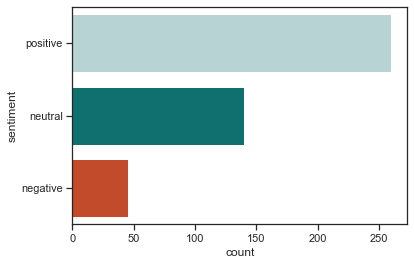

In [55]:
sns.countplot(y='sentiment', 
             data=df, 
             palette=['#b2d8d8',"#008080", '#db3d13']
             );

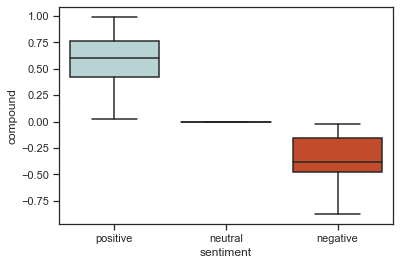

In [56]:
sns.boxplot(y='compound', 
            x='sentiment',
            palette=['#b2d8d8',"#008080", '#db3d13'], 
            data=df);

In [57]:
#social network
translated_text = df['Translation']
translated_text.reset_index(inplace=True, drop=True) # 인덱스 초기화

In [12]:
tokenizer = RegexpTokenizer('[\w]+')
stop_words = stopwords.words('english')+['49','37']

count = {} # 동시출현 빈도가 저장될 dict
for line in translated_text:
    words = line
    tokens = tokenizer.tokenize(words) # 각 리뷰를 토큰화한 뒤 리스트에 저장
    stopped_tokens = [i for i in list(set(tokens)) if not i in stop_words+["br"]]
    stopped_tokens2 = [i for i in stopped_tokens if len(i)>1]
    for i,a in enumerate(stopped_tokens2):
        for b in stopped_tokens2[i+1:]:
            if a>b:
                count[b,a] = count.get((b,a),0) + 1
            else:
                count[a,b] = count.get((a,b),0) + 1
                
df1 = pd.DataFrame.from_dict(count, orient='index')

list1=[]
for i in range(len(df)):
    list1.append([df1.index[i][0], df1.index[i][1], df1[0][i]])

df2 = pd.DataFrame(list1, columns=['term1','term2','freq'])
df3 = df2.sort_values(by=['freq'], ascending=False) # freq 기준으로 내림차순 정렬
df3_nw = df3.reset_index(drop=True)

In [13]:

YT_jp_nw = nx.Graph()

# 동시출현 빈도가 10 이상인 단어들에 대해서만 중심성 계수 계산
for i in range((len(np.where(df3_nw['freq']>1)[0]))):
    YT_jp_nw.add_edge(df3_nw['term1'][i], df3_nw['term2'][i],
                  weight=int(df3_nw['freq'][i]))

dgr = nx.degree_centrality(YT_jp_nw) # 연결 중심성
btw = nx.betweenness_centrality(YT_jp_nw) # 매개 중심성
cls = nx.closeness_centrality(YT_jp_nw) # 근접 중심성
egv = nx.eigenvector_centrality(YT_jp_nw) # 고유벡터 중심성

sorted_dgr = sorted(dgr.items(), key=operator.itemgetter(1), reverse=True)
sorted_btw = sorted(btw.items(), key=operator.itemgetter(1), reverse=True)
sorted_cls = sorted(cls.items(), key=operator.itemgetter(1), reverse=True)
sorted_egv = sorted(egv.items(), key=operator.itemgetter(1), reverse=True)

print("** degree **")
for x in range(10):
    print(sorted_dgr[x])

print("** betweenness **")
for x in range(10):
    print(sorted_btw[x])
    
print("** closeness **")
for x in range(10):
    print(sorted_cls[x])

print("** eigenvector **")
for x in range(10):
    print(sorted_egv[x])

,Unnamed: 0,Translation
0,0,I’m not sure how any other country’s tourism b...
1,1,The Grand Tour is only a fraction of what Swit...
2,2,The paradox of acting:Anne Hathaway nailing ev...
3,3,Anne is just phenomenon in everything. I love ...
4,4,"Federer on the verge of laughing to his lines,..."


In [5]:
nx.draw(YT_jp_nw, pos = nx.spring_layout(YT_jp_nw, k=5),
    node_color='lightgreen', linewidths=0.125, font_size=10,
    font_weight='bold', edge_color= 'pink', with_labels=True)

plt.figure(num=None, figsize=(2000, 2000), dpi=1000)


plt.show()

In [ ]:
nx.draw(YT_kr_nw, node_color='lightyellow', with_labels = True)

In [ ]:
#LDA Topic modeling

df = df.dropna()
df.head()

In [ ]:
vect =TfidfVectorizer(stop_words=stop_words,max_features=1000)
vect_text=vect.fit_transform(df['text_string_lem'])

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
lda_model=LatentDirichletAllocation(n_components=10,
learning_method='online',random_state=42,max_iter=1) 
lda_top=lda_model.fit_transform(vect_text)

In [ ]:
print("Document : ")
for i,topic in enumerate(lda_top[0]):
  print("Topic ",i+1,": ",topic*100,"%")

In [ ]:
vocab = vect.get_feature_names()
for i, comp in enumerate(lda_model.components_):
     vocab_comp = zip(vocab, comp)
     sorted_words = sorted(vocab_comp, key= lambda x:x[1], reverse=True)[:10]
     print("Topic "+str(i)+": ")
     for t in sorted_words:
            print(t[0],end=" ")
            print('\n')